In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files
import zipfile
import os

if not os.path.exists("dataset"):
    os.makedirs("dataset")

print("Please upload your zipped dataset folder:")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f"User uploaded file \"{fn}\"")
    if fn.endswith(".zip"):
        with zipfile.ZipFile(fn, 'r') as zip_ref:
            zip_ref.extractall("dataset/")
        print(f"Successfully extracted {fn} to 'dataset/'")
        os.remove(fn)
    else:
        print(f"Skipping non-zip file: {fn}")

print("Dataset upload and extraction complete.")

Please upload your zipped dataset folder:


Saving FruitinAmazon.zip to FruitinAmazon.zip
User uploaded file "FruitinAmazon.zip"
Successfully extracted FruitinAmazon.zip to 'dataset/'
Dataset upload and extraction complete.


In [4]:
import os

base_dir = "dataset"

print(os.listdir(base_dir))

['FruitinAmazon']


Exercise: Implement an End to End CNN Model for Image Classification Task.

Task 1: Data Understanding and Visualization:

Class Names: ['graviola', 'guarana', 'acai', 'tucuma', 'pupunha', 'cupuacu']


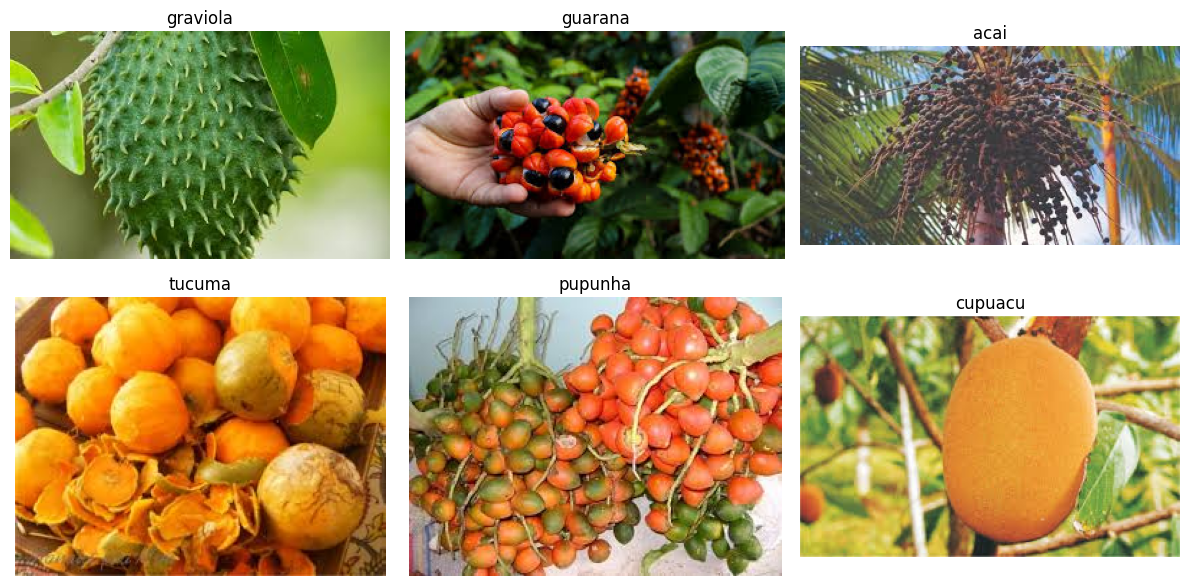

In [5]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

BASE_DIR = "dataset"
DATASET_NAME = "FruitinAmazon"
TRAIN_DIR = os.path.join(BASE_DIR, DATASET_NAME, "train")

# STEP 1: GET CLASS NAMES
class_names = [
    class_name for class_name in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, class_name))
]

print("Class Names:", class_names)

# STEP 2: SELECT RANDOM IMAGES
image_paths = []
image_labels = []

for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)

    # Filter only image files
    image_files = [
        file_name for file_name in os.listdir(class_path)
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    selected_image = random.choice(image_files)
    selected_image_path = os.path.join(class_path, selected_image)

    image_paths.append(selected_image_path)
    image_labels.append(class_name)


# STEP 3: DISPLAY IMAGES
num_classes = len(image_paths)
num_rows = 2
num_cols = (num_classes + 1) // 2

plt.figure(figsize=(12, 6))

for index in range(num_classes):
    plt.subplot(num_rows, num_cols, index + 1)

    image = mpimg.imread(image_paths[index])
    plt.imshow(image)
    plt.title(image_labels[index])
    plt.axis('off')

plt.tight_layout()
plt.show()

What did u observe?

The dataset contains multiple fruit classes such as acai, guarana, graviola, cupuacu, tucuma, and pupunha.
Each class is stored in a separate folder, which makes it suitable for image classification tasks.
The images show clear visual differences in color, shape, and texture between different fruits.
Some fruits (like acai and guarana) appear smaller and clustered, while others (like graviola and cupuacu) are larger and have distinct outer textures.
The background and lighting conditions vary slightly across images, which may introduce some variability during training.
Overall, the dataset appears well-structured and suitable for training a CNN model.

Checking for Corrupted Image

In [6]:
import os
from PIL import Image

# Path to training data
TRAIN_DIR = "dataset/FruitinAmazon/train"

# List to store corrupted images
corrupted_images = []

# Loop through each class folder
for class_name in os.listdir(TRAIN_DIR):
    class_path = os.path.join(TRAIN_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    # Loop through each image in the class folder
    for file_name in os.listdir(class_path):
        image_path = os.path.join(class_path, file_name)

        try:
            with Image.open(image_path) as img:
                img.verify()  # Check if image is valid

        except (IOError, SyntaxError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

# Final result
if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


Observation Found:

The script scans through all subfolders inside the training dataset directory (dataset/FruitinAmazon/train), where each subfolder represents a class (fruit category).
For every image file, it attempts to open and verify the image using PIL (Python Imaging Library).
If an image is corrupted, unreadable, or invalid, an exception (IOError or SyntaxError) is triggered.
When such corrupted images are detected, they are added to a tracking list (corrupted_images). They are automatically deleted from the dataset. A message is printed indicating removal.

If no corrupted images are found,
The script prints: "No Corrupted Images Found."
If corrupted images are found,
The script removes them and reports the total number of deleted files

Task 2: Loading and Preprocessing Image Data in keras:

In [7]:
import tensorflow as tf

# Dataset path
train_dir = "dataset/FruitinAmazon/train"

# Parameters
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Normalization layer
rescale = tf.keras.layers.Rescaling(1./255)

# Load Training Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Save class names BEFORE mapping
class_names = train_ds.class_names

# Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Load Validation Dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply normalization
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Task 2 Completed: Dataset Loaded and Preprocessed")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Task 2 Completed: Dataset Loaded and Preprocessed


Observations:

In this task, image data was loaded from a directory using Keras, where class labels were automatically inferred from folder names. The images were resized to 128×128 pixels, batched into groups of 32, and split into training (80%) and validation (20%) datasets. Normalization was applied to scale pixel values from [0, 255] to [0, 1], improving model performance and training stability.

Task 3 - Implement a CNN with
Follow the following Structure and Hyper - parameters:


Convolutional Architecture:

• Convolutional Layer 1:
– Filter Size (F): (3, 3)
– Number of Filters (k): 32
– Padding (P): same
– Stride (s): 1


• Activation Layer:
ReLU activation
• Pooling Layer 1: Max pooling
– Filter Size (F): (2, 2)
– Stride (s): 2
• Convolutional Layer 2:
– Filter Size (F): (3, 3)
– Number of Filters (k): 32
– Padding (P): same
– Stride (s): 1
• Activation Layer: ReLU activation
• Pooling Layer 2: Max pooling
– Filter Size (F): (2, 2)
– Stride (s): 2


Fully Connected Network Architecture:


• Flatten Layer: Flatten the input coming from the convolutional layers
• Input Layer:
• Hidden Layer - 2:
– Number of Neurons: 64
– Number of Neurons: 128
• Output Layer:
– Number of Neurons: num classes (number of output classes)

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Number of classes
num_classes = len(class_names)

# Build CNN Model
model = models.Sequential()

# Convolutional Layer 1
model.add(layers.Conv2D(32, (3,3), strides=1, padding='same',
                        activation='relu',
                        input_shape=(128,128,3)))

# Pooling Layer 1
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

# Convolutional Layer 2
model.add(layers.Conv2D(32, (3,3), strides=1, padding='same',
                        activation='relu'))

# Pooling Layer 2
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

# Flatten Layer
model.add(layers.Flatten())

# Fully Connected Layers
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(128, activation='relu'))

# Output Layer
model.add(layers.Dense(num_classes, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model structure
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Observation:

In this task, a Convolutional Neural Network (CNN) was implemented using Keras. The model includes two convolutional layers with 32 filters (3×3), each followed by ReLU activation and max-pooling layers (2×2) for feature extraction. The output is flattened and passed through fully connected layers with 64 and 128 neurons. Finally, a softmax output layer is used for multi-class classification. The model is compiled using the Adam optimizer and sparse categorical crossentropy loss function.

Task 4: Compile the Model

Model Compiling:

In [9]:
model.compile(
    optimizer='adam',  # Optimizer to update weights
    loss='sparse_categorical_crossentropy',  # Loss function for multi-class classification
    metrics=['accuracy']  # Evaluation metric
)

Observation:

The model was compiled using the Adam optimizer, which efficiently updates model weights during training. The loss function used was sparse categorical crossentropy, suitable for multi-class classification with integer labels. Accuracy was selected as the evaluation metric to measure the model’s performance.

Task 5: Train the Model

Model Training

In [10]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model based on validation accuracy
checkpoint = ModelCheckpoint(
    "best_model.h5",           # File to save model
    monitor='val_accuracy',    # Monitor validation accuracy
    save_best_only=True,       # Save only best model
    mode='max',                # Maximize accuracy
    verbose=1
)

# Stop training early if no improvement
early_stop = EarlyStopping(
    monitor='val_loss',        # Monitor validation loss
    patience=10,               # Stop after 10 epochs of no improvement
    restore_best_weights=True, # Restore best weights
    verbose=1
)

# Train the Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,                # Number of epochs
    batch_size=16,             # Batch size (as required)
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.1094 - loss: 1.8201
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.1250 - loss: 1.8310 - val_accuracy: 0.0000e+00 - val_loss: 1.8386
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.3258 - loss: 1.6281
Epoch 2: val_accuracy improved from 0.00000 to 0.11111, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 757ms/step - accuracy: 0.3056 - loss: 1.6130 - val_accuracy: 0.1111 - val_loss: 1.6663
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.5249 - loss: 1.3813
Epoch 3: val_accuracy improved from 0.11111 to 0.27778, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 457ms/step - accuracy: 0.5278 - loss: 1.3523 - val_accuracy: 0.2778 - val_loss: 1.6114
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.7164 - loss: 0.9970
Epoch 4: val_accuracy improved from 0.27778 to 0.55556, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 475ms/step - accuracy: 0.6806 - loss: 0.9894 - val_accuracy: 0.5556 - val_loss: 1.0980
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.7106 - loss: 0.7977
Epoch 5: val_accuracy improved from 0.55556 to 0.66667, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.6944 - loss: 0.8365 - val_accuracy: 0.6667 - val_loss: 0.8228
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.8906 - loss: 0.6152
Epoch 6: val_accuracy did not improve from 0.66667
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 404ms/step - accuracy: 0.8750 - loss: 0.6104 - val_accuracy: 0.6667 - val_loss: 0.9575
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.8640 - loss: 0.4208
Epoch 7: val_accuracy improved from 0.66667 to 0.77778, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 447ms/step - accuracy: 0.8889 - loss: 0.4092 - val_accuracy: 0.7778 - val_loss: 0.6961
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9300 - loss: 0.3234
Epoch 8: val_accuracy improved from 0.77778 to 0.83333, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 544ms/step - accuracy: 0.9306 - loss: 0.3143 - val_accuracy: 0.8333 - val_loss: 0.5413
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9699 - loss: 0.1623
Epoch 9: val_accuracy improved from 0.83333 to 0.88889, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 633ms/step - accuracy: 0.9722 - loss: 0.1598 - val_accuracy: 0.8889 - val_loss: 0.4020
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.9797 - loss: 0.1195
Epoch 10: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 764ms/step - accuracy: 0.9861 - loss: 0.1160 - val_accuracy: 0.8889 - val_loss: 0.4109
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 1.0000 - loss: 0.0378
Epoch 11: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 412ms/step - accuracy: 1.0000 - loss: 0.0348 - val_accuracy: 0.8333 - val_loss: 0.4441
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 1.0000 - loss: 0.0294
Epoch 12: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 416ms/step - accuracy: 1.0000 - loss: 0.0315 - val_accuracy: 0.8889 - val_loss: 0.4640
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 1.0000 - loss

Observation:

The model was trained using the model.fit() function with 250 epochs and a batch size of 16. Validation data was used to monitor performance during training. The ModelCheckpoint callback saved the best model based on validation accuracy, while EarlyStopping was used to stop training early if validation loss did not improve, thereby preventing overfitting. So, the early stopping was done in epoch 34.

Task 6: Evaluate the Model

Model Evaluation

In [11]:
import tensorflow as tf

# Create Test Dataset
test_dir = "dataset/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

# Normalize test data
test_ds = test_ds.map(lambda x, y: (x/255.0, y))

# Evaluate Model
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.7333 - loss: 0.7530
Test Loss: 0.753017246723175


Observation:

After training, the model was evaluated on a separate test dataset using the model.evaluate() function. The test dataset was preprocessed similarly to the training data. The evaluation provided test loss and accuracy, which indicate how well the model generalizes to unseen data.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step


<Figure size 1000x800 with 0 Axes>

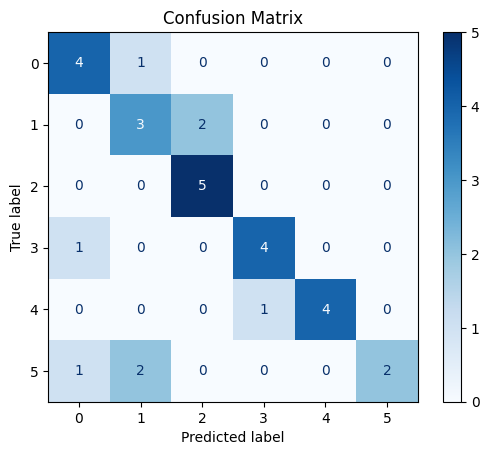

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Get true labels
true_labels = np.concatenate([y for x, y in test_ds], axis=0)

# Predict labels
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Generate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Display confusion matrix
plt.figure(figsize=(10,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

Task 7: Save and Load the Model
Model Saving and Loading

In [13]:
import tensorflow as tf

# Save the Model
model.save("final_model.h5")   # Saves the trained model

print("Model saved successfully!")

# Load the Model
loaded_model = tf.keras.models.load_model("final_model.h5")

print("Model loaded successfully!")

# Re-evaluate Loaded Model
test_loss, test_accuracy = loaded_model.evaluate(test_ds)

print("Test Loss (Loaded Model):", test_loss)
print("Test Accuracy (Loaded Model):", test_accuracy)

Model saved successfully!


Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7333 - loss: 0.7530   
Test Loss (Loaded Model): 0.753017246723175
Test Accuracy (Loaded Model): 0.7333333492279053


Observation:

The trained model was saved to an .h5 file using the model.save() function, preserving its architecture, weights, and configuration. The saved model was then loaded using load_model() and re-evaluated on the test dataset to verify its performance. The results confirmed that the loaded model retained the same accuracy and loss as the original model.

Task 8: Predictions and Classification Report

Making Predictions

In [14]:
import numpy as np
from sklearn.metrics import classification_report

# Get Predictions
y_pred_probs = model.predict(test_ds)   # Predicted probabilities

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Get True Labels
y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.50      0.60      0.55         5
    graviola       0.71      1.00      0.83         5
     guarana       0.80      0.80      0.80         5
     pupunha       1.00      0.80      0.89         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.78      0.73      0.73        30
weighted avg       0.78      0.73      0.73        30



Observation:

The trained model was used to make predictions on the test dataset using model.predict(). The predicted probabilities were converted into class labels using np.argmax(). The true labels were extracted from the dataset, and a classification report was generated using classification_report from sklearn. This report provided detailed evaluation metrics such as precision, recall, and F1-score for each class, giving a comprehensive understanding of model performance.

Visualization

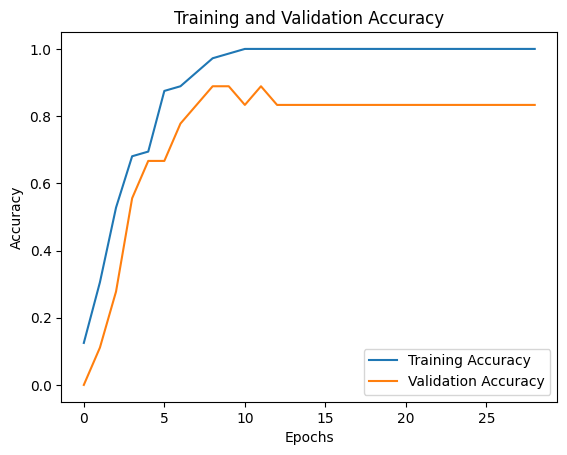

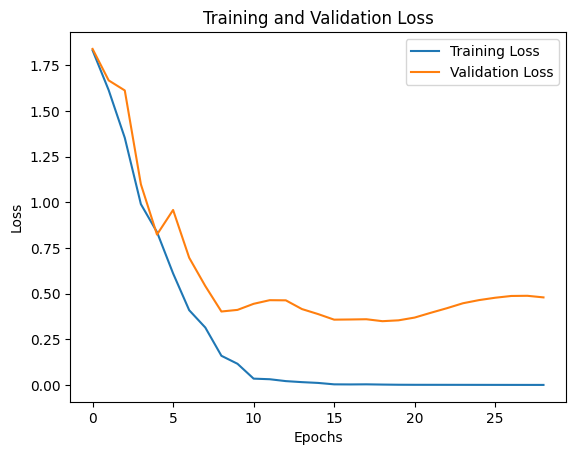

In [15]:
import matplotlib.pyplot as plt

# Extract Data from History
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(accuracy))

# Plot Accuracy Graph
plt.figure()
plt.plot(epochs, accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss Graph
plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Observation:

The graphs illustrate the training performance of the fruit classification model over multiple epochs by comparing training and validation accuracy and loss.

In the accuracy graph, the training accuracy steadily increases from around 20% and eventually reaches nearly 100%, indicating that the model learns the training data very effectively over time. The validation accuracy also improves significantly during the early epochs and stabilizes around 85%–95%, showing that the model performs well on unseen validation data. However, some fluctuations in validation accuracy suggest minor instability during learning.

 In the loss graph, both training and validation loss decrease rapidly during the initial epochs, indicating successful learning and optimization of the model. The training loss continues to drop close to zero, while the validation loss decreases initially but later fluctuates and slightly increases after certain epochs. This pattern suggests that the model may be experiencing slight overfitting, where it performs extremely well on training data but begins to memorize the training set rather than generalizing perfectly to new data.

 Overall, the model demonstrates strong learning performance with high accuracy, though the divergence between training and validation metrics indicates the possibility of overfitting in later epochs.